In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Set environment variables
import os


os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "double"
os.environ["MY_NUMBA_TARGET"] = "numba"
 
 
# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../clonscal")

In [49]:
import numpy as np

lamb = 2
sigma_abs = 1

# number of different phases
start_angle = 0.01
stop_angle = np.pi
num = 5
angles = np.linspace(start_angle, stop_angle, num, endpoint=False)
# angles = np.array([0.001, 1/8, 2/8, 3/8, 7/16, 17/32])*2*np.pi
# angles = np.array([1/8])*2*np.pi
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))
sigma_vals = [-1+4j]
mass_modification = 1
pullback = 10*np.exp(1j*2*np.pi/8)

In [50]:
import numpy as np
from tqdm import tqdm
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from simulation.gpu_handler import GPU_handler
from src.numba_target import (
    use_cuda, 
    my_act_parallel_loop
    )
import src.scal as scal
from src.utils import (
    update_histogram_complex, 
    mexican_hat_kernel_real, 
    update_histogram_complex,
    update_histogram_real,
    )
from src.obs_kernels import (
    n_moment_kernel, 
    abs_drift
)

if use_cuda: from numba import cuda

steps = int(1e5)
trajs = int(5e3)

histograms_p = []
histograms_u = []
for idx_sig, sigma in enumerate(sigma_vals):
    label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \quad Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"


    config = Config(dt = 1e-4, trajs = trajs, dims = [1], mass_real = sigma, interaction = lamb, 
                    ada_step = True, drift_kernel=mexican_hat_kernel_real,)
    sim = ComplexLangevinSimulation(config)

    bins = 1000  # Number of bins
    hist_p = np.zeros((bins, bins), dtype=scal.SCAL_TYPE_REAL)
    hist_u = np.zeros(bins, dtype=scal.SCAL_TYPE_REAL)
    if use_cuda: hist_p = cuda.to_device(hist_p); cuda.to_device(hist_p)
    
    sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={'order': 1}, 
                        langevin_history=False, thermal_time=0.5, auto_corr=0.5)
    sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={'order': 2}, 
                        langevin_history=False, thermal_time=0.5, auto_corr=0.5)
    sim.register_observable('abs_drift', obs_kernel=abs_drift, const_param={'order': 1}, 
                            langevin_history=False, thermal_time=0.5, auto_corr=0.5,dtype=scal.SCAL_TYPE_REAL)
    

    gpu_handler = GPU_handler(sim)
    if use_cuda: gpu_handler.to_device()

    for _ in tqdm(range(steps)):
        sim.step()
        for name, tr in sim.trackers.items():
            tr.mark_equilibrated_trajs()
            tr.compute()

        p_tracker = sim.trackers["1_moment"]
        u_tracker = sim.trackers["abs_drift"]
        my_act_parallel_loop(update_histogram_complex, p_tracker.equilibrated_trajs, trajs, p_tracker.result, hist_p, bins, -10, 10, -10, 10)
        my_act_parallel_loop(update_histogram_real, u_tracker.equilibrated_trajs, trajs, u_tracker.result, hist_u, bins, 0.001, 100)
        if use_cuda: cuda.synchronize()

    sim.finish()
    if use_cuda: gpu_handler.to_host()
    histograms_p.append(hist_p)
    histograms_u.append(hist_u)

100%|██████████| 100000/100000 [00:28<00:00, 3518.18it/s]


In [51]:
# rebin
import numpy as np

def rebin_2d(hist, factor_x, factor_y):
    """
    Rebins a 2D histogram by summing over blocks of (factor_x, factor_y) bins.
    
    Parameters:
        hist (np.ndarray): The original 2D histogram (bins_x, bins_y).
        factor_x (int): Rebinning factor along x (real).
        factor_y (int): Rebinning factor along y (imag).

    Returns:
        np.ndarray: The rebinned histogram.
    """
    bins_x, bins_y = hist.shape
    new_bins_x = bins_x // factor_x
    new_bins_y = bins_y // factor_y
    
    # Ensure dimensions are divisible by factors (trim if necessary)
    hist = hist[:new_bins_x * factor_x, :new_bins_y * factor_y]
    
    # Reshape and sum over blocks
    rebinned_hist = hist.reshape(new_bins_x, factor_x, new_bins_y, factor_y).sum(axis=(1, 3))
    
    return rebinned_hist

def rebin_1d(hist, factor):
    """
    Rebins a 1D histogram by summing over blocks of `factor` bins.

    Parameters:
        hist (np.ndarray): The original 1D histogram (array of bin counts).
        factor (int): The number of adjacent bins to merge into one.

    Returns:
        np.ndarray: The rebinned histogram.
    """
    bins = len(hist)
    new_bins = bins // factor  # Compute the new number of bins

    # Trim the histogram if needed to ensure divisibility
    hist = hist[:new_bins * factor]

    # Reshape and sum over blocks
    rebinned_hist = hist.reshape(new_bins, factor).sum(axis=1)
    
    return rebinned_hist



In [52]:
# solve_floweq
from scipy.integrate import solve_ivp

def stop_event(t, z, *args, **kwargs):
    x, y = z
    return max(x, y) - 10  # Triggers when either x or y reaches 10

stop_event.terminal = True

def solve_floweq(flow_equation, crit_point, epsilon = 0.001, t_span = (0, 100), t_points=10, events = None, **kwargs):
    sigma = kwargs.get("sigma", 5*np.exp(1j*np.pi*3/4)) 
    lamb = kwargs.get("lamb", 1) 

    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol = []
    flow_times = []
    
    directions_num = 4
    angles = np.linspace(0+0.01, 2*np.pi+0.01, directions_num, endpoint=False)
    perturbations = epsilon * np.exp(1j * angles)

    for perturb in perturbations:
        z0 = crit_point + perturb
        z0 = [np.real(crit_point + perturb), np.imag(crit_point + perturb)]

        solution = solve_ivp(flow_equation, t_span, y0 = z0, args = (sigma, lamb), t_eval=t_eval, method="BDF", events=stop_event)
        sol.append(solution.y[0] + 1j * solution.y[1])
        flow_times.append(solution.t)
    return sol, flow_times


In [53]:
# drift func
# unmod
@np.vectorize
def drift_func(z, sigma, lamb):
    return sigma*z+lamb*z**3


def flow_equation_stable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

def flow_equation_unstable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = -np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

In [54]:
# root finder
def F_real(z_real, sigma, lamb):
    z = z_real[0] + 1j * z_real[1]
    drift = sigma*z+lamb*z**3

    return np.array([drift.real, drift.imag])


from scipy.optimize import root as root_scipy
def find_roots(guess, sigma, lamb):
    sol = root_scipy(F_real, guess, method='hybr', args=(sigma, lamb))
    if sol.success:
        root_found = sol.x[0] + 1j * sol.x[1]
        return root_found
    return 0

In [55]:
# action
@np.vectorize
def action_unmod(z, sigma, lamb):
    return sigma/2*z**2+lamb/4*z**4

@np.vectorize
def drift_unmod(z, sigma, lamb):
    return sigma*z+lamb*z**3

In [56]:
# thimble length
def cumulative_curve_length(z):
    """Compute the cumulative length of a curve given by a NumPy array of complex numbers."""
    dz = np.diff(z)  # Differences between consecutive points
    segment_lengths = np.abs(dz)  # Euclidean distance (modulus of complex numbers)
    cumulative_lengths = np.concatenate(([0], np.cumsum(segment_lengths)))  # Cumulative sum
    return cumulative_lengths

In [57]:
def find_min_max(hist, bare_min, bare_max):
    bins = hist.shape[0]
    for idx, val in enumerate(hist[0,:]):
        if val!=0: x_min = idx; break

    for idx, val in enumerate(np.flip(hist, axis=1)[0,:]):
        if val!=0: x_max = idx; break

    for idx, val in enumerate(hist[:,0]):
        if val!=0: y_min = idx; break

    for idx, val in enumerate(np.flip(hist, axis=1)[:,0]):
        if val!=0: y_max = idx; break
    return (x_min, x_max, y_min, y_max)


(1000, 1000)


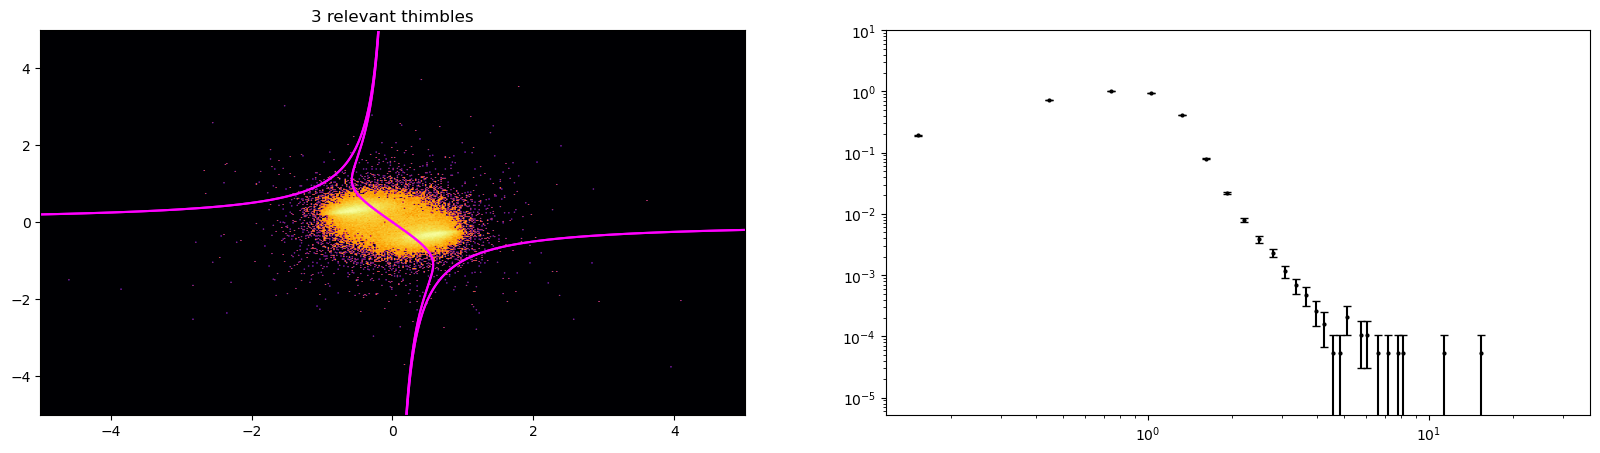

In [58]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

for hist, sigma in zip(histograms_p, sigma_vals):

    fig, ax = plt.subplots(1, 2, figsize=(20, 5))
    print(hist.shape)
    # Histograms
    if use_cuda: 
        hist_host = hist.copy_to_host()
    else: hist_host = rebin_2d(hist, 2, 2)

    hist_host
    min_real, max_real = -2, 2
    min_imag, max_imag = -1, 1

    # Define bin edges for the plot
    real_bins = np.linspace(min_real, max_real, bins)
    imag_bins = np.linspace(min_imag, max_imag, bins)

    real_grid, imag_grid = np.meshgrid(real_bins, imag_bins, indexing='ij')
    U_values = np.abs(drift_func(real_grid + 1j * imag_grid, sigma, lamb))
    U_min, U_max = U_values.min(), U_values.max()

    U_bins = np.linspace(U_min, U_max, 100)
    U_centers = 0.5 * (U_bins[:-1] + U_bins[1:])  # Bin centers
    rho_u = np.histogram(U_values.flatten(), bins = U_bins, weights = hist.flatten(), density=True)
    counts, U_edges = np.histogram(U_values.flatten(), bins=U_bins, weights=hist.flatten(), density=False)
    rho_u_error = np.sqrt(counts) / (np.sum(hist) * np.diff(U_bins))

    ax[1].errorbar(U_centers, rho_u[0], yerr=rho_u_error, fmt='o', color='black', markersize=2, capsize=3)
    ax[1].set_ylim(1e-6, 1)
    ax[1].set_ylim(rho_u[0][rho_u[0]!=0].min()/10, 10*rho_u[0][rho_u[0]!=0].max())
    ax[1].set_yscale("log")
    ax[1].set_xscale("log")
    # Create the figure and axis
    ax[0].imshow(np.log10(hist_host.T+1e-6), origin='lower', aspect='auto', extent=[-5, 5, -5, 5], cmap='inferno')

    x_vals = np.linspace(-5, 5, 10)  # Real part of z
    y_vals = np.linspace(-5, 5, 10)  # Imaginary part of z
    initial_guesses = [(x, y) for x in x_vals for y in y_vals]

    # Thimbles
    roots = []
    for guess in initial_guesses:
        root_found = find_roots(guess, sigma, lamb)
        if not any(np.isclose(root_found, r, atol=1e-6) for r in roots):
            roots.append(root_found)

    cols_idx = np.linspace(0, 1, len(roots))
    num_relevant = 0
    for roo, col in zip(roots,  cm.rainbow(cols_idx)):
        # print(f"drift zero: {roo}")
        solutions, flow_times = solve_floweq(flow_equation_unstable, crit_point=roo, t_span = (0, 100), t_points=100000, 
                                sigma = sigma, lamb=lamb)
                
        relevant = False
        conc_sol = np.concatenate(solutions, axis = 0)
        if any(conc_sol.imag>0) and any(conc_sol.imag<0): relevant = True; num_relevant += 1

        for sol in solutions:
            if relevant: pass
                # ax[0].plot(sol.real, sol.imag, color = "magenta", ls = ':')  # Set transparency for better visibility
            else: pass
                # ax[0].plot(sol.real, sol.imag, color = 'gray', ls = ':')  # Set transparency for better visibility

        # stable
        solutions, flow_times = solve_floweq(flow_equation_stable, crit_point=roo, t_span = (0, 100), t_points=100000, sigma = sigma, lamb=lamb)
        for sol, fl_time in zip(solutions, flow_times):
            # ax[1].set_title(len(solutions))
            if relevant: 
                # print(f"minimal action: {np.min(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification)))}")
                # print(f"maximal action: {np.max(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification)))}")
                ax[0].plot(sol.real, sol.imag, color = "magenta", ls = "solid")
            else:
                ax[0].plot(sol.real, sol.imag, color = 'gray', ls = "solid", alpha=0.6, lw = 0.6)  # Set transparency for better visibility
        # ax[0].set_xlim(-5, 5)
        # ax[0].set_ylim(-2, 2)
        ax[0].set_xlim(-5, 5)
        ax[0].set_ylim(-5, 5)
        ax[0].set_title(f"{num_relevant} relevant thimbles")

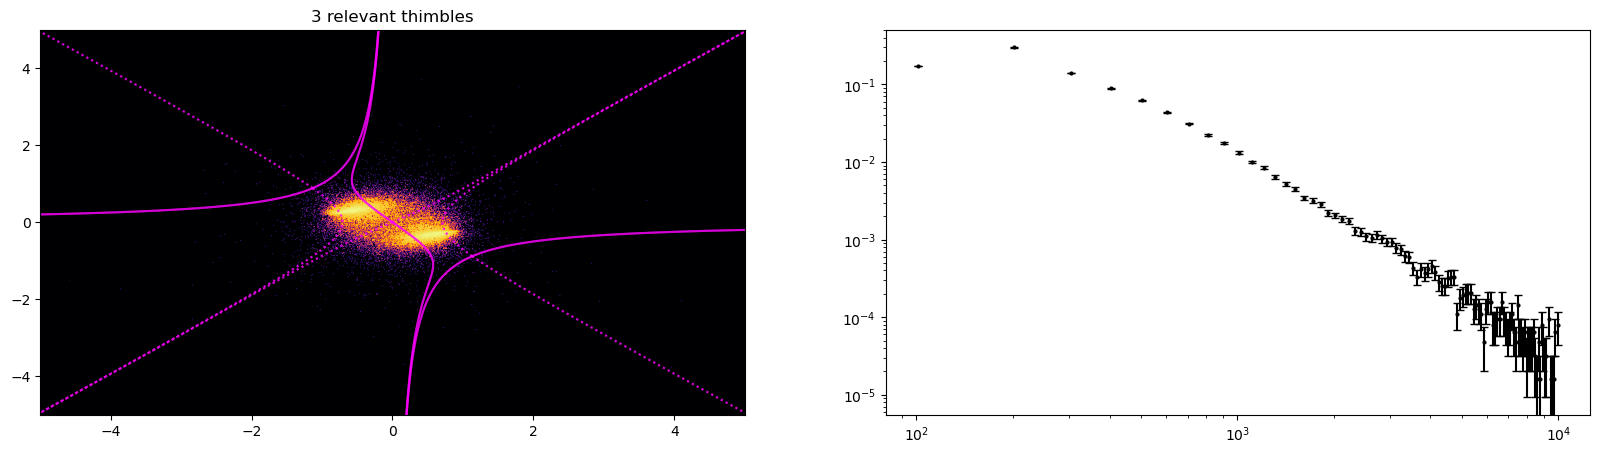

In [59]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

for hist_p, hist_u, sigma in zip(histograms_p, histograms_u, sigma_vals):

    fig, ax = plt.subplots(1, 2, figsize=(20, 5))

    hist_u = rebin_1d(hist_u,10)
    hist_u_norm = hist_u / np.sum(hist_u)

# Compute relative errors (Poisson errors scaled by total count)
    errors = np.sqrt(hist_u) / np.sum(hist_u)  # Normalize errors

    U_min, U_max = 0, 1e4
    U_bins = np.linspace(U_min, U_max, len(hist_u_norm))
    U_centers = 0.5 * (U_bins[:-1] + U_bins[1:])  # Bin centers
    ax[1].errorbar(U_bins, hist_u_norm, yerr=errors, fmt='o', color='black', markersize=2, capsize=3)
    ax[1].set_yscale("log")
    ax[1].set_xscale("log")
    # Create the figure and axis
    ax[0].imshow(np.log10(hist_p.T+1e-6), origin='lower', aspect='auto', extent=[-5, 5, -5, 5], cmap='inferno')

    x_vals = np.linspace(-5, 5, 10)  # Real part of z
    y_vals = np.linspace(-5, 5, 10)  # Imaginary part of z
    initial_guesses = [(x, y) for x in x_vals for y in y_vals]

    # Thimbles
    roots = []
    for guess in initial_guesses:
        root_found = find_roots(guess, sigma, lamb)
        if not any(np.isclose(root_found, r, atol=1e-6) for r in roots):
            roots.append(root_found)

    cols_idx = np.linspace(0, 1, len(roots))
    num_relevant = 0
    for roo, col in zip(roots,  cm.rainbow(cols_idx)):
        # print(f"drift zero: {roo}")
        solutions, flow_times = solve_floweq(flow_equation_unstable, crit_point=roo, t_span = (0, 100), t_points=100000, 
                                sigma = sigma, lamb=lamb)
                
        relevant = False
        conc_sol = np.concatenate(solutions, axis = 0)
        if any(conc_sol.imag>0) and any(conc_sol.imag<0): relevant = True; num_relevant += 1

        for sol in solutions:
            if relevant:
                ax[0].plot(sol.real, sol.imag, color = "magenta", ls = ':', alpha = 0.6)  # Set transparency for better visibility
            else: pass
                # ax[0].plot(sol.real, sol.imag, color = 'gray', ls = ':')  # Set transparency for better visibility

        # stable
        solutions, flow_times = solve_floweq(flow_equation_stable, crit_point=roo, t_span = (0, 100), t_points=100000, sigma = sigma, lamb=lamb)
        for sol, fl_time in zip(solutions, flow_times):
            # ax[1].set_title(len(solutions))
            if relevant: 
                # print(f"minimal action: {np.min(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification)))}")
                # print(f"maximal action: {np.max(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification)))}")
                ax[0].plot(sol.real, sol.imag, color = "magenta", ls = "solid", alpha = 0.6)
            else:
                ax[0].plot(sol.real, sol.imag, color = 'gray', ls = "solid", alpha=0.6, lw = 0.6)  # Set transparency for better visibility
        # ax[0].set_xlim(-5, 5)
        # ax[0].set_ylim(-2, 2)
        ax[0].set_xlim(-5, 5)
        ax[0].set_ylim(-5, 5)
        ax[0].set_title(f"{num_relevant} relevant thimbles")

In [60]:
def calculate_stats_complex(rolling_mean, rolling_sqr_mean, counter):
    """
    Calculate mean and SEM for complex numbers.
    
    Parameters:
    rolling_mean (np.array): Single-element array containing the rolling sum of complex values.
    rolling_sqr_mean (np.array): Single-element array containing the rolling sum of squared magnitudes of complex values.
    counter (np.array): Single-element array containing the number of values.
    
    Returns:
    tuple: (mean, sem_real, sem_imag), where:
        - mean is the complex mean,
        - sem_real is the SEM for the real part,
        - sem_imag is the SEM for the imaginary part.
    """
    if counter == 0:
        raise ValueError("Counter cannot be zero to avoid division by zero.")
    
    # Extract real and imaginary parts
    rolling_mean_real = rolling_mean.real
    rolling_mean_imag = rolling_mean.imag
    
    # Mean calculation
    mean_real = rolling_mean_real / counter
    mean_imag = rolling_mean_imag / counter
    
    # Variance for real part
    rolling_sqr_mean_real = rolling_sqr_mean
    variance = (rolling_sqr_mean_real / counter) - mean_real**2 - mean_imag**2
    variance = max(variance, 0)
        
    # Standard error of the mean (SEM)
    sem = np.sqrt(variance / counter)
    
    # Return complex mean and SEM for real and imaginary parts
    mean = mean_real + 1j * mean_imag
    return mean, sem


In [61]:
calculate_stats_complex(sim.trackers["2_moment"].rolling_mean, sim.trackers["2_moment"].rolling_sqr_mean, sim.trackers["2_moment"].counter)

((0.4565395710946237-0.8512292154544815j), 0.009715772475147728)